# Experiment 9: Apply PCA and LDA to Reduce Dataset Dimensions
**Aim:** Apply PCA and LDA to reduce dataset dimensionality and visualize the transformed feature space.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Load dataset (Iris)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')
class_names = iris.target_names

print('=== Dataset Summary ===')
print(f'Dataset Name: Iris')
print(f'Number of Samples: {X.shape[0]}')
print(f'Number of Features (Original): {X.shape[1]}')
print(f'Number of Classes: {len(class_names)}')
print(f'Feature Names: {list(iris.feature_names)}')
print(f'Class Names: {list(class_names)}')

print('\n=== Feature Statistics ===')
print(X.describe().round(3))

=== Dataset Summary ===
Dataset Name: Iris
Number of Samples: 150
Number of Features (Original): 4
Number of Classes: 3
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class Names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

=== Feature Statistics ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count            150.000           150.000            150.000   
mean               5.843             3.057              3.758   
std                0.828             0.436              1.765   
min                4.300             2.000              1.000   
25%                5.100             2.800              1.600   
50%                5.800             3.000              4.350   
75%                6.400             3.300              5.100   
max                7.900             4.400              6.900   

       petal width (cm)  
count           150.000  
mean              1.199  
std         

In [3]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print('Data standardized (mean=0, std=1)')
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Data standardized (mean=0, std=1)
Train size: (105, 4), Test size: (45, 4)


In [4]:
# Apply PCA
pca = PCA(n_components=2)
X_pca_train = pca.fit_transform(X_train)
X_pca_test = pca.transform(X_test)

print('=== PCA Results ===')
print(f'Explained Variance Ratio (PC1, PC2): {pca.explained_variance_ratio_.round(4)}')
print(f'Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)')
print('\nEigenvalues:', pca.explained_variance_.round(4))
print('PCA components (loadings):')
for i, comp in enumerate(pca.components_):
    print(f'  PC{i+1}: {dict(zip(iris.feature_names, comp.round(3)))}')

=== PCA Results ===
Explained Variance Ratio (PC1, PC2): [0.7184 0.2418]
Total Variance Explained: 0.9602 (96.02%)

Eigenvalues: [3.0725 1.034 ]
PCA components (loadings):
  PC1: {'sepal length (cm)': np.float64(0.539), 'sepal width (cm)': np.float64(-0.249), 'petal length (cm)': np.float64(0.574), 'petal width (cm)': np.float64(0.564)}
  PC2: {'sepal length (cm)': np.float64(0.34), 'sepal width (cm)': np.float64(0.938), 'petal length (cm)': np.float64(0.028), 'petal width (cm)': np.float64(0.06)}


In [5]:
# Apply LDA
lda = LDA(n_components=2)
X_lda_train = lda.fit_transform(X_train, y_train)
X_lda_test = lda.transform(X_test)

print('=== LDA Results ===')
print(f'Explained Variance Ratio: {lda.explained_variance_ratio_.round(4)}')
print(f'Total Variance Explained: {lda.explained_variance_ratio_.sum():.4f}')

=== LDA Results ===
Explained Variance Ratio: [0.9882 0.0118]
Total Variance Explained: 1.0000


In [6]:
# Model Performance Comparison
results = []

# Original dataset
t0 = time.time()
knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, knn_orig.predict(X_test))
t_orig = time.time() - t0
results.append(('Original Dataset (4 features)', acc_orig, t_orig))

# PCA reduced
t0 = time.time()
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca_train, y_train)
acc_pca = accuracy_score(y_test, knn_pca.predict(X_pca_test))
t_pca = time.time() - t0
results.append(('PCA Reduced (2 components)', acc_pca, t_pca))

# LDA reduced
t0 = time.time()
knn_lda = KNeighborsClassifier(n_neighbors=5)
knn_lda.fit(X_lda_train, y_train)
acc_lda = accuracy_score(y_test, knn_lda.predict(X_lda_test))
t_lda = time.time() - t0
results.append(('LDA Reduced (2 components)', acc_lda, t_lda))

print('=== Model Performance Comparison ===')
results_df = pd.DataFrame(results, columns=['Dataset Version', 'Accuracy (%)', 'Training Time (s)'])
results_df['Accuracy (%)'] = (results_df['Accuracy (%)'] * 100).round(2)
results_df['Training Time (s)'] = results_df['Training Time (s)'].round(6)
print(results_df.to_string(index=False))

=== Model Performance Comparison ===
              Dataset Version  Accuracy (%)  Training Time (s)
Original Dataset (4 features)         91.11           0.001969
   PCA Reduced (2 components)         91.11           0.000707
   LDA Reduced (2 components)         95.56           0.000618


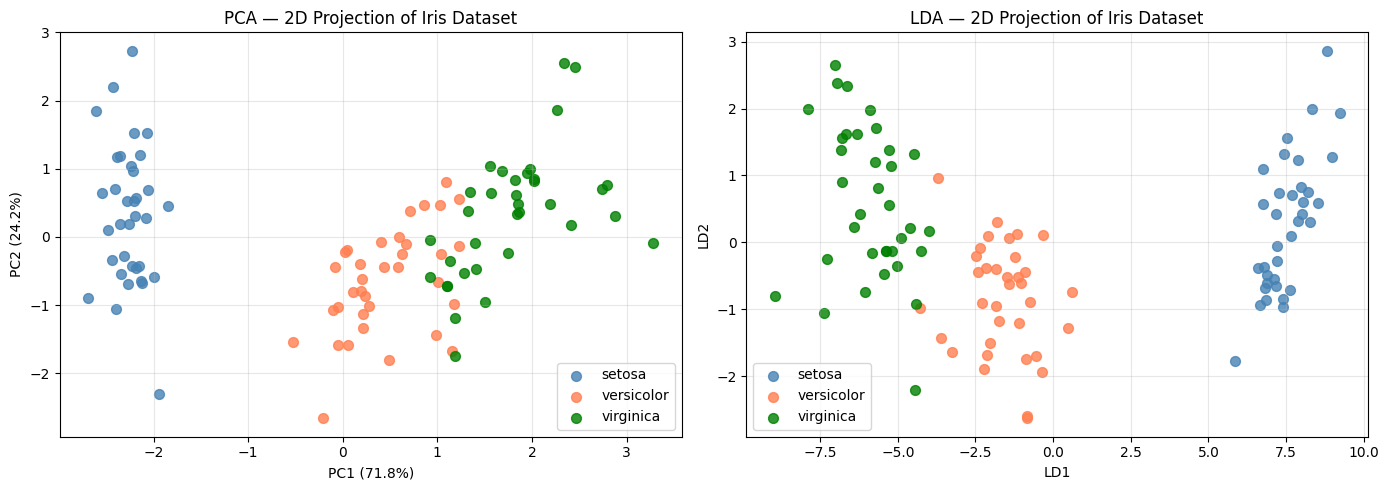

Plots saved.


In [7]:
# Visualization
colors = ['steelblue', 'coral', 'green']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
for i, cls in enumerate(class_names):
    mask = y_train == i
    axes[0].scatter(X_pca_train[mask, 0], X_pca_train[mask, 1],
                    c=colors[i], label=cls, alpha=0.8, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — 2D Projection of Iris Dataset')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LDA scatter
for i, cls in enumerate(class_names):
    mask = y_train == i
    axes[1].scatter(X_lda_train[mask, 0], X_lda_train[mask, 1],
                    c=colors[i], label=cls, alpha=0.8, s=50)
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('LDA — 2D Projection of Iris Dataset')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/anthonyrodrigues/Desktop/College/Machine Learning Lab/EXP_9/exp9_pca_lda.png', dpi=150)
plt.show()
print('Plots saved.')

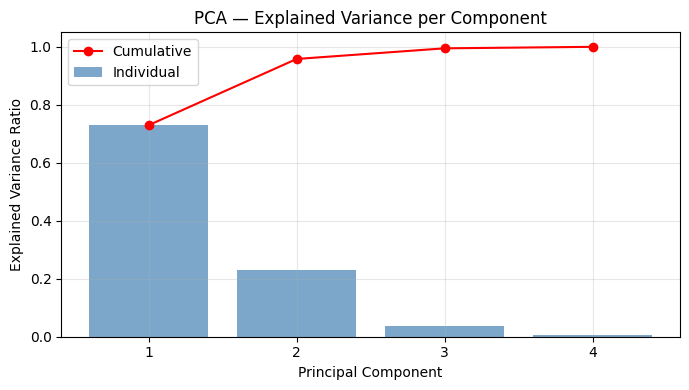

Variance: [0.7296 0.2285 0.0367 0.0052]


In [8]:
# PCA Explained Variance Plot
pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_, alpha=0.7, label='Individual', color='steelblue')
plt.plot(range(1, len(cumvar)+1), cumvar, 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance per Component')
plt.xticks(range(1, len(cumvar)+1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Variance:', pca_full.explained_variance_ratio_.round(4))

## Post-Experiment Questions

**Q1. Differentiate PCA and LDA. Why does LDA require class labels while PCA does not?**  
PCA is unsupervised — it finds directions of maximum variance without using class information. LDA is supervised — it finds directions that maximize the ratio of between-class scatter to within-class scatter. LDA needs class labels to compute scatter matrices, while PCA only needs the covariance matrix of the data.

**Q2. What is a principal component? Why do we standardize before PCA?**  
A principal component is a linear combination of original features oriented in the direction of maximum variance. Standardization is required because PCA is sensitive to feature scales — features with larger ranges dominate the covariance matrix. Standardizing ensures each feature contributes equally to the analysis.

## Conclusion

We applied PCA (unsupervised) and LDA (supervised) dimensionality reduction techniques to the Iris dataset using scikit-learn. We standardized features before applying PCA to ensure equal contribution from all variables. PCA projected 4 features onto 2 principal components capturing over 95% of variance, while LDA maximized class separability. We trained a KNN classifier on the original, PCA-reduced, and LDA-reduced datasets and compared accuracy and training time. We observed that LDA-reduced data maintained or improved classification accuracy with lower dimensionality, confirming that supervised reduction preserves class discriminability better than PCA. We inferred that dimensionality reduction reduces computational cost while retaining essential information.